# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV884"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv884')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv884/lv884-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV884,gene_band
0,ZNF658,5.685500,9q21.11
1,FBXW4,5.171299,10q24.32
2,PPARGC1B,2.842164,5q32
3,UPF3A,2.405158,13q34
4,ZNF2,1.609075,2q11.1
5,ANKH,1.574047,5p15.2
6,HECW2,1.420468,2q32.3
7,GRIK1,1.419604,21q21.3
8,CACNA1I,1.409713,22q13.1
9,GPHN,1.325580,14q23.3


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-04-22 22:00:35,543 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-04-22 22:00:35,543 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP057196, SRP058773, SRP066834, SRP042161, SRP055569, SRP033135, SRP060416, SRP063840, SRP059379, SRP050499, SRP030617, SRP002326, SRP009266, SRP005279, SRP015435, SRP017777, SRP025982, SRP014688, SRP039591, SRP015013, SRP002958, SRP055153, SRP064464, SRP007338, SRP007596, SRP011422, SRP051737, SRP044286, SRP033464, SRP067701, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (29 != 30)
  warnings.warn(


In [12]:
lv_data.shape

(6473, 59)

In [13]:
lv_data.head()

tissue        cell type               age c1 chip id  \
project   run                                                                
SRP057196 SRR1975007  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975008  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975006  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975005  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975004  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   

                     experiment_sample_name well number  \
project   run                                             
SRP057196 SRR1975007                  FB_S6         NaN   
          SRR1975008                  FB_S6         NaN   
          SRR1975006                  FB_S6         NaN   
          SRR1975005                  FB_S6         NaN   
          SRR1975004                  FB_S6         NaN   

                     reprogramming time point (day) Stage cell line  \
project   run                                                         
SRP057196 SRR1975007                            NaN   NaN       NaN   
          SRR1975008                            NaN   NaN       NaN   
          SRR1975006                            NaN   NaN       NaN   
          SRR1975005                            NaN   NaN       NaN   
          SRR1975004                            NaN   NaN       NaN   

                     patient id  ... qc pass cell count ercc_mix  \
project   run                    ...                               
SRP057196 SRR1975007        NaN  ...     NaN        NaN      NaN   
          SRR1975008        NaN  ...     NaN        NaN      NaN   
          SRR1975006        NaN  ...     NaN        NaN      NaN   
          SRR1975005        NaN  ...     NaN        NaN      NaN   
          SRR1975004        NaN  ...     NaN        NaN      NaN   

                     ercc_dilution library type read length transfection  \
project   run                                                              
SRP057196 SRR1975007           NaN          NaN         NaN          NaN   
          SRR1975008           NaN          NaN         NaN          NaN   
          SRR1975006           NaN          NaN         NaN          NaN   
          SRR1975005           NaN          NaN         NaN          NaN   
          SRR1975004           NaN          NaN         NaN          NaN   

                     cell state donor     LV884  
project   run                                    
SRP057196 SRR1975007        NaN   NaN -0.037194  
          SRR1975008        NaN   NaN -0.171580  
          SRR1975006        NaN   NaN  0.265982  
          SRR1975005        NaN   NaN -0.163573  
          SRR1975004        NaN   NaN  0.215965  

[5 rows x 59 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

c1 chip id                                0.113670
experiment_sample_name                    0.113670
age                                       0.112248
well number                               0.068226
reprogramming time point (day)            0.068226
tissue                                    0.046122
cell type                                 0.019438
iPSc                                      0.011729
reprogramming vector                      0.011729
time                                      0.011729
Stage                                     0.009868
cytogenetic background                    0.005136
facs gating                               0.005023
tonsil donor                              0.005023
patient id                                0.004949
dilutions of the malignant b-cell line    0.004472
developmental stage                       0.002783
gender                                    0.002760
diagnosis                                 0.002432
subtype                        

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue       0.046122
cell type    0.019438
cell line    0.001158
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "tissue",
    "cell type",
    "cell line",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

tissue                               cell type  \
project   run                                                                   
SRP057196 SRR1974866           cortex                                 neurons   
          SRR1974663           cortex                                 neurons   
          SRR1974619           cortex                                  hybrid   
SRP058773 SRR2042653              NaN                                     NaN   
SRP066834 SRR2967826  Fetal neocortex                                     NaN   
SRP042161 SRR1295030              NaN                            Glioblastoma   
SRP057196 SRR1974767           cortex                                 neurons   
          SRR1974775           cortex                                 neurons   
          SRR1974656           cortex                                 neurons   
          SRR1974642           cortex                                 neurons   
          SRR1974967           cortex                         fetal_quiescent   
SRP055569 SRR1821669              NaN        MCF10a human breast cancer cells   
SRP057196 SRR1974996           cortex                         fetal_quiescent   
SRP066834 SRR2967614  Fetal neocortex                                     NaN   
SRP033135 SRR1033017              NaN  Human Skeletal Muscle Myoblasts (HSMM)   
SRP060416 SRR2088282              NaN            tonsil Innate lymphoid cells   
SRP057196 SRR1974640           cortex                                 neurons   
          SRR1974613           cortex                                 neurons   
SRP060416 SRR2088136              NaN            tonsil Innate lymphoid cells   
SRP057196 SRR1974636           cortex                                 neurons   
SRP060416 SRR2088075              NaN            tonsil Innate lymphoid cells   
SRP055569 SRR1821659              NaN        MCF10a human breast cancer cells   
SRP057196 SRR1974872           cortex                                 neurons   
SRP060416 SRR2088342              NaN            tonsil Innate lymphoid cells   
          SRR2088277              NaN            tonsil Innate lymphoid cells   

                     cell line     LV884  
project   run                             
SRP057196 SRR1974866       NaN  5.717010  
          SRR1974663       NaN  3.099754  
          SRR1974619       NaN  1.957292  
SRP058773 SRR2042653       NaN  1.856828  
SRP066834 SRR2967826       NaN  1.803408  
SRP042161 SRR1295030       NaN  1.222614  
SRP057196 SRR1974767       NaN  0.848781  
          SRR1974775       NaN  0.766037  
          SRR1974656       NaN  0.662530  
          SRR1974642       NaN  0.616490  
          SRR1974967       NaN  0.559147  
SRP055569 SRR1821669       NaN  0.558231  
SRP057196 SRR1974996       NaN  0.488286  
SRP066834 SRR2967614       NaN  0.458076  
SRP033135 SRR1033017       NaN  0.452222  
SRP060416 SRR2088282       NaN  0.439618  
SRP057196 SRR1974640       NaN  0.430575  
          SRR1974613       NaN  0.402369  
SRP060416 SRR2088136       NaN  0.397412  
SRP057196 SRR1974636       NaN  0.394741  
SRP060416 SRR2088075       NaN  0.381402  
SRP055569 SRR1821659       NaN  0.356729  
SRP057196 SRR1974872       NaN  0.349560  
SRP060416 SRR2088342       NaN  0.348308  
          SRR2088277       NaN  0.337444

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue  \
project   run                                                             
SRP057196 SRR1974798                                        hippocampus   
          SRR1974657                                             cortex   
SRP066834 SRR2967784                                    Fetal neocortex   
          SRR2967282                Dissociated whole cerebral organoid   
SRP060416 SRR2088261                                                NaN   
SRP057196 SRR1974986                                             cortex   
SRP066834 SRR2967301                Dissociated whole cerebral organoid   
          SRR2967480  Microdissected cortical-like ventricle from ce...   
SRP063840 SRR2431375                                                NaN   
SRP066834 SRR2967736                                    Fetal neocortex   
SRP055569 SRR2019070                                                NaN   
SRP057196 SRR1974952                                             cortex   
SRP066834 SRR2967745                                    Fetal neocortex   
SRP059379 SRR2060560                                                NaN   
SRP055569 SRR1821607                                                NaN   
SRP033135 SRR1032991                                                NaN   
SRP057196 SRR1974711                                             cortex   
SRP042161 SRR1294505                                                NaN   
SRP060416 SRR2088602                                                NaN   
SRP066834 SRR2967678                                    Fetal neocortex   
          SRR2967775                                    Fetal neocortex   
SRP057196 SRR1974746                                             cortex   
          SRR1974568                                             cortex   
          SRR1975006                                             cortex   
          SRR1974780                                             cortex   

                                                              cell type  \
project   run                                                             
SRP057196 SRR1974798                                        endothelial   
          SRR1974657                                            neurons   
SRP066834 SRR2967784                                                NaN   
          SRR2967282                                                NaN   
SRP060416 SRR2088261                       tonsil Innate lymphoid cells   
SRP057196 SRR1974986                                    fetal_quiescent   
SRP066834 SRR2967301                                                NaN   
          SRR2967480                                                NaN   
SRP063840 SRR2431375                    metastatic renal cell carcinoma   
SRP066834 SRR2967736                                                NaN   
SRP055569 SRR2019070                  WI-38 human lung fibroblast cells   
SRP057196 SRR1974952                                    fetal_quiescent   
SRP066834 SRR2967745                                                NaN   
SRP059379 SRR2060560                       iPSC-derived cortical neuron   
SRP055569 SRR1821607  mixture of U87 human glioma cells and MCF10a h...   
SRP033135 SRR1032991             Human Skeletal Muscle Myoblasts (HSMM)   
SRP057196 SRR1974711                                            neurons   
SRP042161 SRR1294505                                       Glioblastoma   
SRP060416 SRR2088602                       tonsil Innate lymphoid cells   
SRP066834 SRR2967678                                                NaN   
          SRR2967775                                                NaN   
SRP057196 SRR1974746                                             hybrid   
          SRR1974568                                             hybrid   
          SRR1975006                                    fetal_quiescent   
          SRR1974780                                            neurons   

             

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

tissue  \
project   run                      
SRP039591 SRR1186052      Spleen   
          SRR1186053      Spleen   
          SRR1186054      Spleen   
          SRR1186056      Spleen   
          SRR1186055     culture   
          SRR1186057  Lymph node   
          SRR1186058  Lymph node   
          SRR1186059      Spleen   

                                                              diagnosis  \
project   run                                                             
SRP039591 SRR1186052               Hepatosplenic T-cell lymphoma (HSTL)   
          SRR1186053               Hepatosplenic T-cell lymphoma (HSTL)   
          SRR1186054               Hepatosplenic T-cell lymphoma (HSTL)   
          SRR1186056                                      normal tissue   
          SRR1186055               Hepatosplenic T-cell lymphoma (HSTL)   
          SRR1186057  Peripheral T-cell lymphoma not otherwise speci...   
          SRR1186058  Peripheral T-cell lymphoma not otherwise speci...   
          SRR1186059  Peripheral T-cell lymphoma not otherwise speci...   

                                                              karyotype  \
project   run                                                             
SRP039591 SRR1186052  45-46,X,-Y,-4,der(7)add(7)(p22)add(7)(q32), i(...   
          SRR1186053  46-47,XY,add(4)(p16),i(7)(q10),+8[4],-[20],+ma...   
          SRR1186054  40-48,XY,+X  [3],-5[4],i(7)(q10),+8[5],+10[2],...   
          SRR1186056                                                 NA   
          SRR1186055   46,XY,add(5)(q?),i(7)(q10),-10[5][cp15]c .aCGH+8   
          SRR1186057                              46,XX,t(1;5)(p34;q22)   
          SRR1186058  38-47,XX,+X[10],+2[12],+3[2],del(6)(q15q25),+7...   
          SRR1186059  35-47,X,-X[9],?der(2)dup(2)(q13q23),+3[2],t(3;...   

                         LV884  
project   run                   
SRP039591 SRR1186052  0.103615  
          SRR1186053  0.093883  
          SRR1186054  0.062972  
          SRR1186056  0.018242  
          SRR1186055  0.012020  
          SRR1186057 -0.005355  
          SRR1186058 -0.005884  
          SRR1186059 -0.011148

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "tissue",
    "cell type",
    "cell line",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

tissue     LV884
project   run                                                         
SRP057196 SRR1974866                                  cortex  5.717010
          SRR1974663                                  cortex  3.099754
          SRR1974619                                  cortex  1.957292
SRP058773 SRR2042653                         NOT CATEGORIZED  1.856828
SRP066834 SRR2967826                         Fetal neocortex  1.803408
SRP042161 SRR1295030                            Glioblastoma  1.222614
SRP057196 SRR1974767                                  cortex  0.848781
          SRR1974775                                  cortex  0.766037
          SRR1974656                                  cortex  0.662530
          SRR1974642                                  cortex  0.616490
          SRR1974967                                  cortex  0.559147
SRP055569 SRR1821669        MCF10a human breast cancer cells  0.558231
SRP057196 SRR1974996                                  cortex  0.488286
SRP066834 SRR2967614                         Fetal neocortex  0.458076
SRP033135 SRR1033017  Human Skeletal Muscle Myoblasts (HSMM)  0.452222
SRP060416 SRR2088282            tonsil Innate lymphoid cells  0.439618
SRP057196 SRR1974640                                  cortex  0.430575
          SRR1974613                                  cortex  0.402369
SRP060416 SRR2088136            tonsil Innate lymphoid cells  0.397412
SRP057196 SRR1974636                                  cortex  0.394741

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['cortex',
 'NOT CATEGORIZED',
 'Fetal neocortex',
 'Glioblastoma',
 'MCF10a human breast cancer cells']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

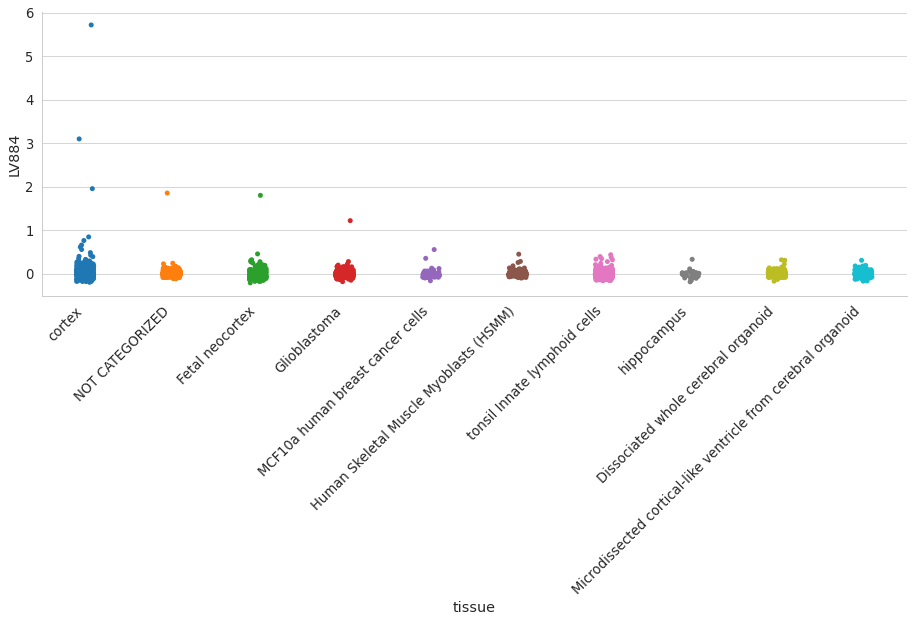

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("NOT CAT")
    ]
    display(_tmp.head(20))

tissue     LV884
project   run                                  
SRP058773 SRR2042653  NOT CATEGORIZED  1.856828
SRP050499 SRR2013684  NOT CATEGORIZED  0.244267
          SRR2013573  NOT CATEGORIZED  0.230135
          SRR2013528  NOT CATEGORIZED  0.174242
          SRR2013497  NOT CATEGORIZED  0.158305
          SRR2013686  NOT CATEGORIZED  0.155924
          SRR2013705  NOT CATEGORIZED  0.150219
          SRR2013560  NOT CATEGORIZED  0.146561
          SRR2013673  NOT CATEGORIZED  0.143621
          SRR2013572  NOT CATEGORIZED  0.141787
          SRR2013546  NOT CATEGORIZED  0.140852
          SRR2013589  NOT CATEGORIZED  0.137945
          SRR2013552  NOT CATEGORIZED  0.135347
          SRR2013498  NOT CATEGORIZED  0.133720
          SRR2013523  NOT CATEGORIZED  0.128750
          SRR2013579  NOT CATEGORIZED  0.128469
          SRR2013502  NOT CATEGORIZED  0.125602
          SRR2013517  NOT CATEGORIZED  0.122896
SRP058773 SRR2042625  NOT CATEGORIZED  0.122479
SRP050499 SRR2013668  NOT CATEGORIZED  0.118576

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP058773, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP058773"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

well number reprogramming time point (day)     LV884
project   run                                                            
SRP058773 SRR2042653           9                             10  1.856828
          SRR2042625          43                             10  0.122479
          SRR2042609          60                             10  0.090927
          SRR2042621          39                             10  0.090133
          SRR2042616          61                             10  0.065480
          SRR2042613          76                             10  0.051660
          SRR2042639          68                             10  0.045765
          SRR2042608          91                             10  0.041472
          SRR2042657          81                             10  0.040750
          SRR2042632          58                             10  0.040283
          SRR2042633          84                             10  0.036946
          SRR2042649          73                             10  0.035331
          SRR2042647           6                             10  0.032526
          SRR2042648          69                             10  0.030952
          SRR2042630          21                             10  0.025310
          SRR2042638          26                             10  0.021205
          SRR2042641          11                             10  0.020499
          SRR2042635          88                             10  0.019839
          SRR2042620          56                             10  0.009003
          SRR2042615          90                             10  0.007782
          SRR2042618          14                             10  0.005233
          SRR2042614          23                             10  0.000952
          SRR2042607          22                             10 -0.000489
          SRR2042643          65                             10 -0.000773
          SRR2042628          74                             10 -0.002366
          SRR2042644          44                             10 -0.003519
          SRR2042627          89                             10 -0.009241
          SRR2042646          48                             10 -0.011143
          SRR2042656          32                             10 -0.011174
          SRR2042619          35                             10 -0.015899
          SRR2042611          34                             10 -0.016221
          SRR2042634          16                             10 -0.016850
          SRR2042642          30                             10 -0.017265
          SRR2042629          92                             10 -0.021521
          SRR2042640          72                             10 -0.024867
          SRR2042612          38                             10 -0.026981
          SRR2042622          18                             10 -0.027661
          SRR2042631          63                             10 -0.029906
          SRR2042617          40                             10 -0.038190
          SRR2042626          59                             10 -0.039608
          SRR2042636          54                             10 -0.039691
          SRR2042610          41                             10 -0.040098
          SRR2042650          10                             10 -0.043585
          SRR2042623          77                             10 -0.043888
          SRR2042645          27                             10 -0.045911
          SRR2042637          45                             10 -0.046864
          SRR2042654          66                             10 -0.050634
          SRR2042624          20                             10 -0.055007
          SRR2042659          50                             10 -0.055114
          SRR2042652          31                             10 -0.059836
          SRR2042658          67                             10 -0.062993
          SRR2042655           5                             10 -0.065370

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.